# Análisis predictivo de datos - Evaluación 1

**Condiciones de entrega de la evaluación:**

- Debe entregar un archivo en formato .ipynb.
- El código debe correr correctamente cuando las celdas se ejecutan de manera secuencial.
- Debe entregar el código ya ejecutado.
- Elimine previamente todo el código que sea basura, solo entregue el código que de respuesta a lo que se le pide que haga.

Con el archivo de datos suministrado, va a crear un modelo de aprendizaje de máquina que prediga la variable **Weight**. Para escoger el modelo a utilizar se debe tener en cuenta que esta variable es **numérica** o **cuantitativa**.

Información sobre este archivo, incluido el diccionario de datos, la puede obtener en [Kaggle](https://www.kaggle.com/datasets/samruddhim/olympics-althlete-events-analysis).

## Carga y análisis exploratorio

Reporte los hallazgos en un celda de texto.

Cargue el archivo de datos, haga un breve análisis exploratorio y descarte las variables con alguna de estas condiciones:

- son claves primarias,
- tienen valores únicos,
- son redundantes con respecto a otras variables del dataset, o
- representan un riesgo de filtración de datos.

Gestione los datos duplicados y los datos nulos. En el caso de la variable **Medal**, impute a los datos nulos el valor **No medal**.

In [8]:
import pandas as pd

df = pd.read_csv('/content/athlete_events.csv',
                sep=',',
)

df =  df.drop_duplicates()
df.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN


In [9]:
# tipo de dato de cada variable y cantidad de valores nulos.
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 269731 entries, 0 to 271115
Data columns (total 15 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   ID      269731 non-null  int64  
 1   Name    269731 non-null  object 
 2   Sex     269731 non-null  object 
 3   Age     260416 non-null  float64
 4   Height  210917 non-null  float64
 5   Weight  208204 non-null  float64
 6   Team    269731 non-null  object 
 7   NOC     269731 non-null  object 
 8   Games   269731 non-null  object 
 9   Year    269731 non-null  int64  
 10  Season  269731 non-null  object 
 11  City    269731 non-null  object 
 12  Sport   269731 non-null  object 
 13  Event   269731 non-null  object 
 14  Medal   39772 non-null   object 
dtypes: float64(3), int64(2), object(10)
memory usage: 32.9+ MB


In [10]:
# Estadisticas descriptivas de las variables numéricas.
df.describe()

,ID,Age,Height,Weight,Year
count,269731.000000,260416.000000,210917.000000,208204.000000,269731.000000
mean,68264.949591,25.454776,175.338953,70.701778,1978.623073
std,39026.253843,6.163869,10.518507,14.349027,29.752055
min,1.000000,10.000000,127.000000,25.000000,1896.000000
25%,34655.500000,21.000000,168.000000,60.000000,1960.000000
50%,68233.000000,24.000000,175.000000,70.000000,1988.000000
75%,102111.000000,28.000000,183.000000,79.000000,2002.000000
max,135571.000000,97.000000,226.000000,214.000000,2016.000000


In [11]:
# Estadisticas descriptivas de las variables categóricas.
df.describe(include='object').T

,count,unique,top,freq
Name,269731,134732,Heikki Ilmari Savolainen,39
Sex,269731,2,M,195353
Team,269731,1184,United States,17598
NOC,269731,230,USA,18604
Games,269731,51,2000 Summer,13821
Season,269731,2,Summer,221167
City,269731,42,London,22297
Sport,269731,66,Athletics,38624
Event,269731,765,Football Men's Football,5733
Medal,39772,3,Gold,13369


In [15]:
# Descartar las variables que no aportan información para el análisis predictivo.
df.drop(columns=['ID', 'Name', 'Games', 'NOC', 'City'], inplace=True)

In [13]:
df['Medal'].fillna('No medal', inplace=True)
df.dropna(inplace=True)
df.info()

/tmp/ipykernel_963/2147963353.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Medal'].fillna('No medal', inplace=True)


<class 'pandas.core.frame.DataFrame'>
Index: 206152 entries, 0 to 271115
Data columns (total 15 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   ID      206152 non-null  int64  
 1   Name    206152 non-null  object 
 2   Sex     206152 non-null  object 
 3   Age     206152 non-null  float64
 4   Height  206152 non-null  float64
 5   Weight  206152 non-null  float64
 6   Team    206152 non-null  object 
 7   NOC     206152 non-null  object 
 8   Games   206152 non-null  object 
 9   Year    206152 non-null  int64  
 10  Season  206152 non-null  object 
 11  City    206152 non-null  object 
 12  Sport   206152 non-null  object 
 13  Event   206152 non-null  object 
 14  Medal   206152 non-null  object 
dtypes: float64(3), int64(2), object(10)
memory usage: 25.2+ MB


### Carga y analisis exploratorio

- **Claves primaria**: ID (identificador único de atleta)
- **Valores unicos**: Name (Esta variable puede ser tratado como un identificador, incluso en el dataset mencionan que es una variable con valores unicos).
- **Variables redundantes**:
    - Games: es redundante si se mantienen Year y Season por separado, ya que Games es una combinación de ambos.
    - NOC: es redundante si se mantiene Team, ya que Team suele ser más específico y NOC está muy correlacionado con el equipo.
    - City: está estrechamente relacionada con Games.
- **Representan un riesgo de filtración**: Medal presenta un riesgo de filtración, aunque se gestionará imputando los nulos con No medal.


Haga un análisis de las variables categóricas no descartadas, e identifique:

- Variables nominales.
- Variables ordinales.
- Variables con alta cardinalidad.
- Variables con categorías atípicas.

Indique qué tipo de procesamiento debería recibir cada una de las variables, de acuerdo con los resultados del análisis anterior.

Reporte los resultados del análisis en una celda de texto.

In [16]:
# variables categóricas y sus categorías

cat_vars = df.select_dtypes(include=["object"]).columns
for col in cat_vars:
    print(f'La columna "{col}" tiene las siguientes categorías: \n {df[col].unique()} \n')

La columna "Sex" tiene las siguientes categorías: 
 ['M' 'F'] 

La columna "Team" tiene las siguientes categorías: 
 ['China' 'Netherlands' 'United States' 'Finland' 'Norway' 'Romania'
 'Estonia' 'France' 'Spain' 'Egypt' 'Bulgaria' 'Italy' 'Azerbaijan'
 'Russia' 'Argentina' 'Cuba' 'Belarus' 'Greece' 'Cameroon' 'Mexico'
 'Soviet Union' 'Nicaragua' 'Hungary' 'Nigeria' 'Algeria' 'Kuwait'
 'Bahrain' 'Pakistan' 'Iraq' 'Lebanon' 'Qatar' 'Malaysia' 'Iran' 'Canada'
 'Ireland' 'Australia' 'South Africa' 'Morocco' 'Eritrea' 'Tanzania'
 'Jordan' 'Sudan' 'Tunisia' 'Libya' 'Belgium' 'Djibouti' 'Comoros'
 'Kazakhstan' 'Brunei' 'Saudi Arabia' 'Maldives' 'Ethiopia' 'Indonesia'
 'Philippines' 'Uzbekistan' 'United Arab Emirates' 'Kyrgyzstan'
 'Tajikistan' 'Unified Team' 'Japan' 'Japan-1' 'Brazil' 'West Germany'
 'East Germany' 'Germany' 'Israel' 'Sweden' 'United States Virgin Islands'
 'Turkey' 'Sri Lanka' 'Armenia' "Cote d'Ivoire" 'Kenya' 'Benin' 'France-1'
 'Ukraine' 'Ghana' 'Somalia' 'Latvia' 'Syria'

In [17]:
# Estadisticas descriptivas de las variables categóricas.
df.describe(include='object').T

,count,unique,top,freq
Sex,206152,2,M,139441
Team,206152,660,United States,13707
Season,206152,2,Summer,166693
Sport,206152,56,Athletics,32374
Event,206152,590,Ice Hockey Men's Ice Hockey,3825
Medal,206152,4,No medal,175971


### Análisis de Variables Categóricas No Descartadas

- Variables nominales: Sex(M y F), Season(Summer y Winter), Team, Sport.
- Variables ordinales: Medal (Gold, silver, bronze)
- Variables con alta cardinalidad: Team, event.
- Variables con categorias atipicas: Ninguna
- ordinal encoder: Medal
- OneHot encoder: Para el resto de las variables categoricas.

Haga un análisis de las variables cuantitativas no descartadas, e identifique:

- Variables que son aproximadamente normales.
- Variables con datos atípicos.

Indique qué tipo de procesamiento debería recibir cada una de las variables, según su distribución y la presencia de valores atípicos.

Reporte los resultados del análisis en una celda de texto.

array([[<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Height'}>],
       [<Axes: title={'center': 'Weight'}>,
        <Axes: title={'center': 'Year'}>]], dtype=object)

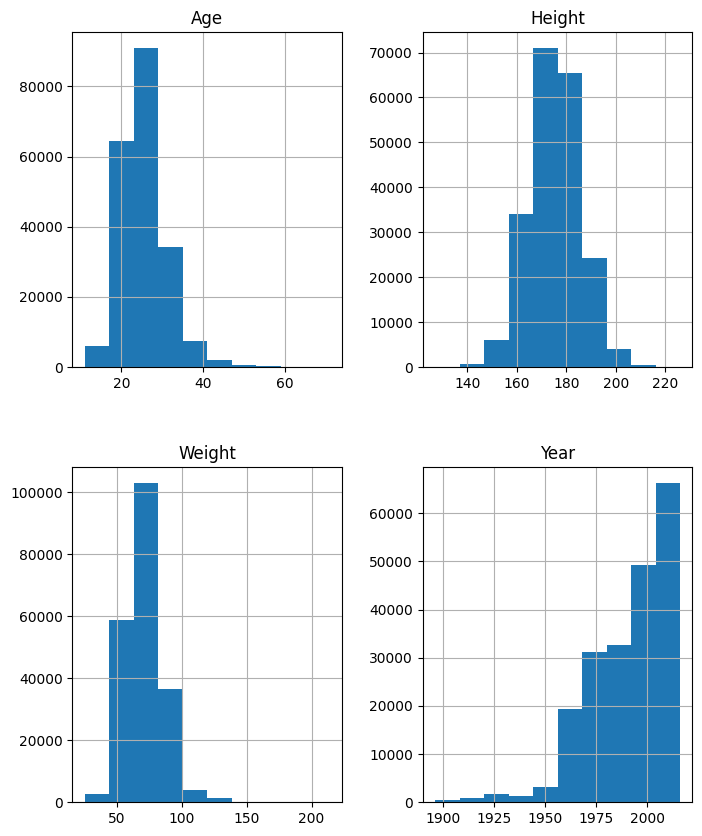

In [18]:
# Visualización de los datos
df.hist(figsize=(8, 10))

array([[<Axes: ylabel='Density'>, <Axes: ylabel='Density'>,
        <Axes: ylabel='Density'>],
       [<Axes: ylabel='Density'>, <Axes: ylabel='Density'>,
        <Axes: ylabel='Density'>],
       [<Axes: ylabel='Density'>, <Axes: ylabel='Density'>,
        <Axes: ylabel='Density'>]], dtype=object)

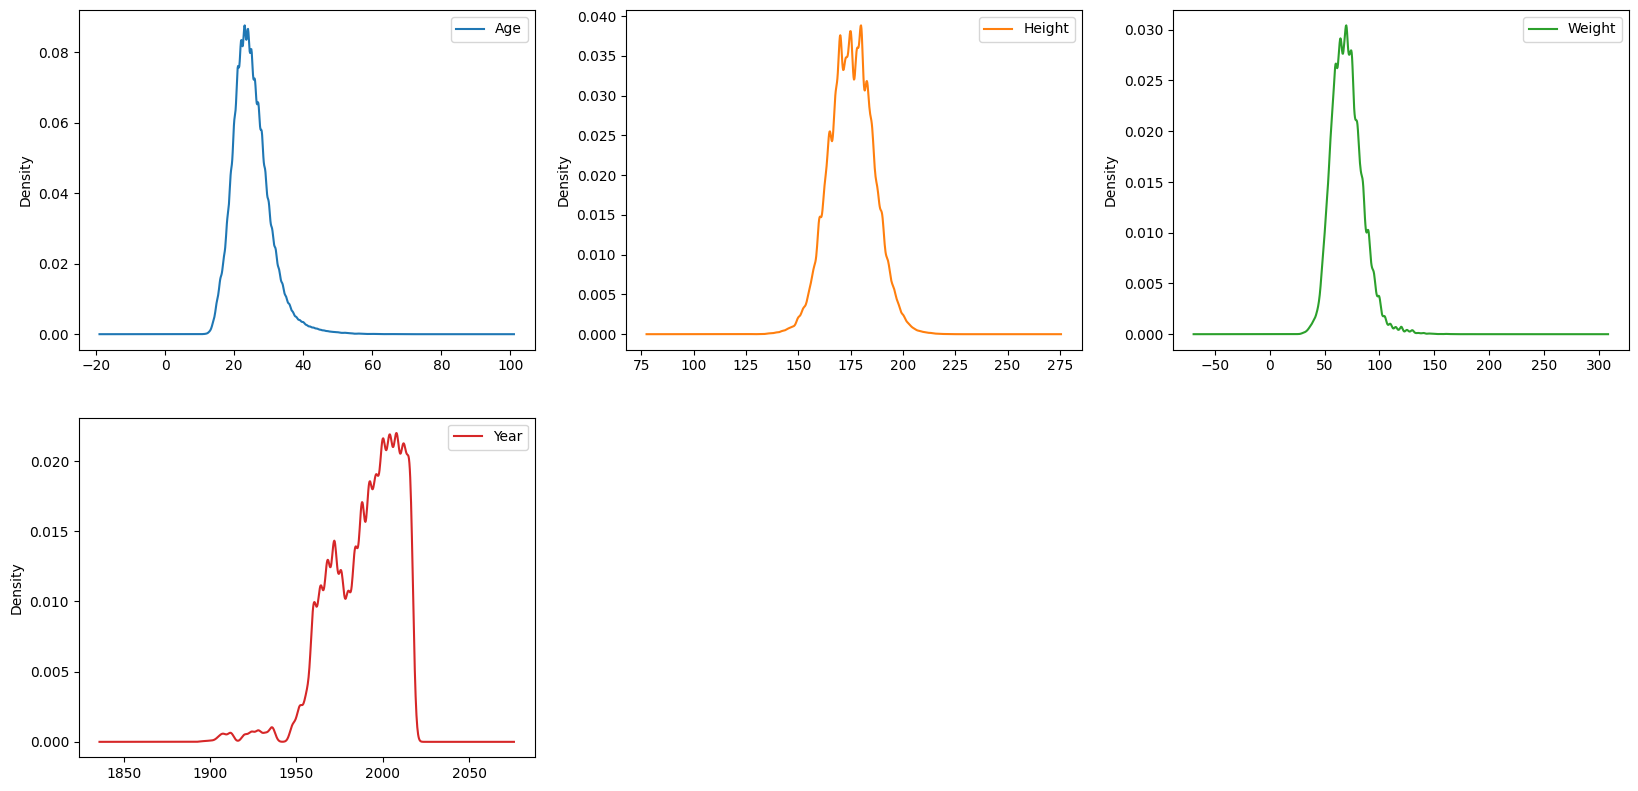

In [19]:
df.select_dtypes(include=['int64', 'float64']).plot(
    kind='kde',
    figsize=(20, 15),
    subplots=True,
    layout=(3, 3),
    sharex=False,
    sharey=False
    )

In [20]:
from scipy.stats import kstest

num_vars = df.select_dtypes(include=["number"]).columns

for num in num_vars:
    __, p_value = kstest(df[num], 'norm', args=(df[num].mean(), df[num].std()))
    print(f"Prueba de Kolmogorov-Smirnov para {num}:")
    print(f"  Valor p: {p_value}")
    if p_value > 0.05:
        print(f"  {num} parece ser normal (no se rechaza la hipótesis nula)")
    else:
        print(f"  {num} no parece ser normal (se rechaza la hipótesis nula)")
    print()

Prueba de Kolmogorov-Smirnov para Age:
  Valor p: 0.0
  Age no parece ser normal (se rechaza la hipótesis nula)

Prueba de Kolmogorov-Smirnov para Height:
  Valor p: 7.976418940811679e-209
  Height no parece ser normal (se rechaza la hipótesis nula)

Prueba de Kolmogorov-Smirnov para Weight:
  Valor p: 0.0
  Weight no parece ser normal (se rechaza la hipótesis nula)

Prueba de Kolmogorov-Smirnov para Year:
  Valor p: 0.0
  Year no parece ser normal (se rechaza la hipótesis nula)



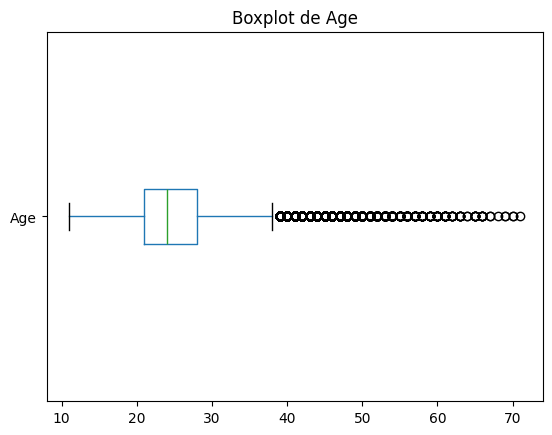

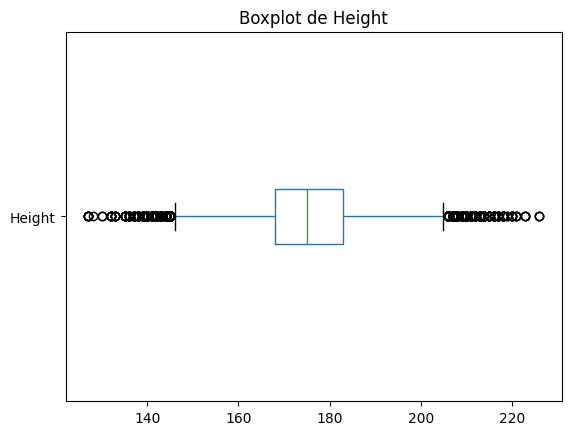

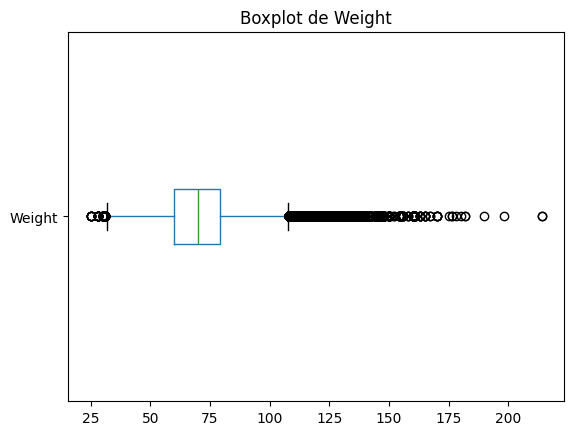

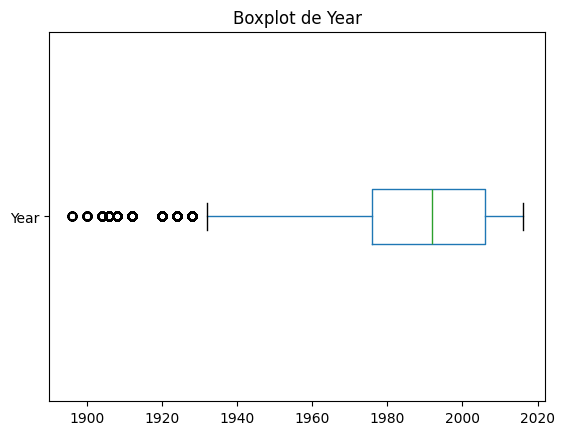

In [21]:
# Datos atipicos boxplot
import matplotlib.pyplot as plt

for num in num_vars:
    plt.figure()
    df.boxplot(column=num, grid=False, vert=False)
    plt.title(f'Boxplot de {num}')
    plt.show()

###Análisis de las variables cuantitativas

-   **Normalidad**: Ninguna variable cumple con el supuesto de normalidad (según la prueba de Kolmogorov-Smirnov y graficos).
-   **Datos atípicos**: Todas las variables cuantitativas (Age, Height, Weight, Year) presentan *outliers* según los boxplots visualizados.
-   **Variables descartadas**: Las variables descartadas fueron ID, Name, Games, NOC, y City, según el análisis inicial de redundancia y riesgo de filtración.

###tipo de procesamiento

StandardScaler(): Age, height, wight,year


Haga análisis bivariados entre las variables de su dataset y la variable objetivo, e identifique que variables serían potencialmente buenas predictoras y cuales no.

Reporte sus resultados en una celda de texto.

In [22]:
df.select_dtypes('number').corr()

,Age,Height,Weight,Year
Age,1.000000,0.141675,0.212061,0.089607
Height,0.141675,1.000000,0.796589,0.048135
Weight,0.212061,0.796589,1.000000,0.022190
Year,0.089607,0.048135,0.022190,1.000000


<Axes: >

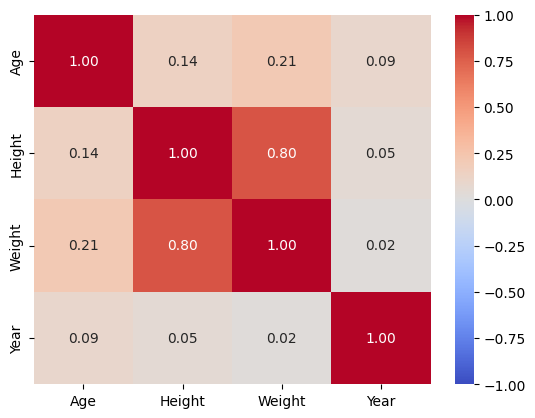

In [23]:
import seaborn as sns

corr = df.select_dtypes('number').corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)

## Procesamiento de las características y entrenamiento del modelo

Cree el matriz de características $X$ con todos las variables no descartadas de su dataframe, menos la variable **Weight**, que será su variable objetivo $y$.

Particione los datos en subconjuntos de entrenamiento y prueba, en un relacion 80/20, usando `random_state=1`.

Para una primera versión de su modelo, seleccione 5 características a procesar que, de acuerdo con el análisis exploratorio realizado, parezcan ser buenas predictoras. Dentro de las 5 debe haber al menos una característica ordinal y dos nominales.

Empaquete las transformaciones que aplicará a estas características usando `ColumnTransformer`. Use el parámetro `remainder='drop'`para descartar las variables que no va a procesar.

Para el modelado va a usar un modelo de regresión logística. Cree un flujo de trabajo que integre el procesamiento y el modelado usando `Pipeline`.

Entrene el modelo y reporte los scores de entrenamiento y de prueba.

Reporte las características con las que **realmente** fue entrenado el modelo, es decir, las resultantes del paso de procesamiento.

In [36]:
# Dividir los datos en conjunto de entrenamiento y prueba
from sklearn.model_selection import train_test_split

x=df.drop(columns=['Weight'])
y=df['Weight']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=1)
print(f'Tamaño del conjunto de entrenamiento es: {x_train.shape}')
print(f'Tamaño del conjunto de prueba es: {x_test.shape}')

Tamaño del conjunto de entrenamiento es: (164921, 9)
Tamaño del conjunto de prueba es: (41231, 9)


In [37]:
x_train


,Sex,Age,Height,Team,Year,Season,Sport,Event,Medal
269615,M,31.0,172.0,Poland,1972,Summer,Hockey,Hockey Men's Hockey,No medal
205442,M,33.0,157.0,Norway,1996,Summer,Wrestling,"Wrestling Men's Flyweight, Greco-Roman",No medal
140804,F,41.0,165.0,China,2012,Summer,Shooting,Shooting Women's Trap,No medal
43716,F,22.0,161.0,Philippines,1960,Summer,Swimming,Swimming Women's 100 metres Freestyle,No medal
84481,F,18.0,167.0,Romania,1976,Summer,Gymnastics,Gymnastics Women's Floor Exercise,No medal
...,...,...,...,...,...,...,...,...,...
98216,F,29.0,165.0,Switzerland,1998,Winter,Cross Country Skiing,Cross Country Skiing Women's 5 kilometres,No medal
144497,F,24.0,174.0,Switzerland,2014,Winter,Ice Hockey,Ice Hockey Women's Ice Hockey,Bronze
67064,M,36.0,183.0,Great Britain,2000,Summer,Equestrianism,"Equestrianism Mixed Dressage, Team",No medal
6870,M,22.0,171.0,Cuba,1952,Summer,Athletics,Athletics Men's 110 metres Hurdles,No medal


In [39]:
df.head()

,Sex,Age,Height,Weight,Team,Year,Season,Sport,Event,Medal
0,M,24.0,180.0,80.0,China,1992,Summer,Basketball,Basketball Men's Basketball,No medal
1,M,23.0,170.0,60.0,China,2012,Summer,Judo,Judo Men's Extra-Lightweight,No medal
4,F,21.0,185.0,82.0,Netherlands,1988,Winter,Speed Skating,Speed Skating Women's 500 metres,No medal
5,F,21.0,185.0,82.0,Netherlands,1988,Winter,Speed Skating,"Speed Skating Women's 1,000 metres",No medal
6,F,25.0,185.0,82.0,Netherlands,1992,Winter,Speed Skating,Speed Skating Women's 500 metres,No medal


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler, OrdinalEncoder

# categoricas
orden=[['No medal', 'Bronze', 'Silver', 'Gold']]

ore = OrdinalEncoder(categories=orden)
ohe = OneHotEncoder(drop='if_binary', sparse_output=False)

variables_numericas=['Age', 'Height', 'Weight', 'Year']

# Escalado de las variables numéricas
ss = StandardScaler()
column_transformer = ColumnTransformer(
    transformers=[('ordinal encoder', ore, ['Medal']),
                  ('one hot encoder', ohe, ['Team', 'Year', 'Season', 'Sport, 'Event'] ),
                  ('standard scaler', ss, ['Age', 'Height', 'Weight', 'Year'])],
    remainder='drop') # El resto de las características se descartan

column_transformer

Vuelva a entrenar el modelo, pero esta vez añada 2 características adicionales.

Reporte los scores de entrenamiento y de prueba del modelo reentrenado.

Reporte las características con las que **realmente** fue reentrenado el modelo, es decir, las resultantes del paso de procesamiento.